<a href="https://colab.research.google.com/github/TetianaMar-888/Python_for_ds_tasks/blob/main/Marinoshenko_Tetiana_3_1_HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn import metrics
from datetime import datetime

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [3]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/marketing_campaign.csv', sep='\t')
print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

Пропуски лише в колонці Income . Їх 24. І в цій же колонці присутній аутлаєр.

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [4]:
data[data['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [5]:
print(data[data['Income'].isnull()][['Education', 'Marital_Status', 'Kidhome', 'Teenhome']])
null_percentage = round(data['Income'].isnull().sum() / data.shape[0] * 100, 2)
print(null_percentage)

       Education Marital_Status  Kidhome  Teenhome
10    Graduation        Married        1         0
27    Graduation         Single        1         0
43           PhD         Single        0         0
48    Graduation         Single        2         1
58    Graduation         Single        1         0
71      2n Cycle        Married        1         0
90           PhD        Married        2         1
91    Graduation         Single        1         1
92        Master       Together        0         0
128          PhD        Married        0         1
133   Graduation        Married        0         1
312   Graduation        Married        0         0
319   Graduation         Single        1         2
1379      Master       Together        0         1
1382  Graduation       Together        1         1
1383    2n Cycle         Single        1         1
1386         PhD       Together        1         0
2059      Master       Together        1         1
2061         PhD         Single

In [6]:
data['Income'].fillna(data['Income'].median(), inplace=True)
data.isnull().sum()

/tmp/ipykernel_11171/2444012779.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Income'].fillna(data['Income'].median(), inplace=True)


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Оскільки пропусків лише 24 значення - це 1,07 % від всих значень. Тому заміняємо медіаною, вона стійка до викидів, а вони в нас є. І для кластерізації дані краще не видаляти, тому що може вплинути на інші кластери.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [7]:
#Перевожу колонку Dt_Customer в колонку скільки днів є клієнтом
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')
data['Customer_Days'] = (data['Dt_Customer'].max() - data['Dt_Customer']).dt.days
#Колонку з роком народження переводжу в вік клієнта
data['Age'] = datetime.now().year - data['Year_Birth']

In [8]:
#Об'єднуємо в Single три лишні значення
print(data['Marital_Status'].value_counts())

data['Marital_Status'] = data['Marital_Status'].replace({
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Alone': 'Single'
})

print(data['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [9]:
#Роблю One-Hot Encoding
categorical_columns = ['Education', 'Marital_Status']
data = pd.get_dummies(data, columns=categorical_columns)

In [10]:
print(data.columns.tolist())


['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Customer_Days', 'Age', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']


In [11]:
# Видаляємо оригінальні колонки (Dt_Customer, Year_Birth)
data.drop(['Dt_Customer', 'Year_Birth'], axis=1, inplace=True)

In [12]:
data.drop(['ID'], axis=1, inplace=True)

In [13]:
print(data.shape)
print(data.columns.tolist())

(2240, 36)
['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Customer_Days', 'Age', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']


In [14]:
print(data['Z_CostContact'].unique())
print(data['Z_Revenue'].unique())

[3]
[11]


Такі колонки як Z_CostContact та Z_Revenue є константними і не несуть жодної інформації для кластеризації — алгоритм не зможе використати їх для розділення клієнтів на групи. Крім того, при масштабуванні даних StandardScaler спробує поділити на стандартне відхилення, яке дорівнює 0, що призведе до помилки. Тому ці колонки видаляються.

In [15]:
data.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [16]:
data.keys()

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Customer_Days', 'Age',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow'],
      dtype='object')

In [17]:
X = data.copy()

In [18]:
# KMeans на 3 кластери
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Метрика силуету
score = silhouette_score(X, labels)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.538


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [19]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df['Cluster'] = labels.astype(str)

# Візуалізація
fig = px.scatter_3d(
    pca_df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    title='KMeans Clusters (PCA 3D)'
)
fig.show()

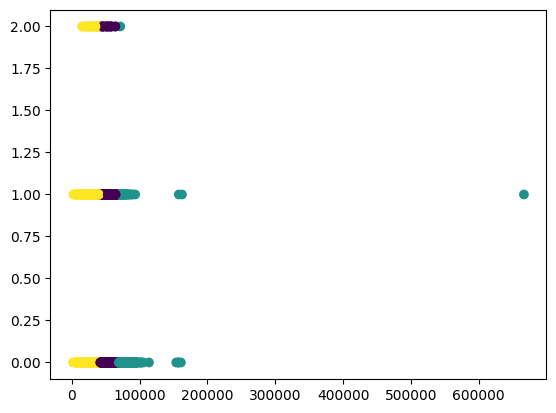

In [20]:
X_numpy = X.values

plt.scatter(X_numpy[:, 0], X_numpy[:, 1], c=labels)
plt.show()

In [21]:
# Додаємо потрібні колонки до pca_df
pca_df['Income'] = X['Income'].values
pca_df['Recency'] = X['Recency'].values
pca_df['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                         X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds']).values

fig = px.scatter_3d(
    pca_df,
    x='Income',
    y='Recency',
    z='TotalSpent',
    color='Cluster',
    title='KMeans Clusters: Income vs Recency vs TotalSpent'
)
fig.show()

In [22]:
#Додаємо ще кількість покупок
pca_df['TotalPurchases'] = (X['NumDealsPurchases'] + X['NumWebPurchases'] +
                             X['NumCatalogPurchases'] + X['NumStorePurchases']).values

fig = px.scatter_3d(
    pca_df,
    x='Income',
    y='Recency',
    z='TotalSpent',
    color='Cluster',
    size='TotalPurchases',  # кількість покупок = розмір точки
    title='KMeans Clusters: Income vs Recency vs TotalSpent vs TotalPurchases'
)
fig.show()

In [23]:
print(pca_df.groupby('Cluster')[['Income', 'Recency', 'TotalSpent', 'TotalPurchases']].mean().round(2))

           Income  Recency  TotalSpent  TotalPurchases
Cluster                                               
0        54161.95    49.70      549.17           16.80
1        79448.16    48.99     1336.34           20.91
2        28991.10    48.56       99.79            8.05


In [24]:
# 1. Додаємо колонки
pca_df['Income'] = X['Income'].values
pca_df['Recency'] = X['Recency'].values
pca_df['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                         X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds']).values
pca_df['TotalPurchases'] = (X['NumDealsPurchases'] + X['NumWebPurchases'] +
                             X['NumCatalogPurchases'] + X['NumStorePurchases']).values

# 2. Називаємо кластери
cluster_names = {
    '0': 'Середній сегмент',
    '1': 'VIP клієнти',
    '2': 'Економні'
}
pca_df['Cluster_Name'] = pca_df['Cluster'].map(cluster_names)

# 3. Будуємо графік
fig = px.scatter_3d(
    pca_df,
    x='Income',
    y='Recency',
    z='TotalSpent',
    color='Cluster_Name',
    size='TotalPurchases',
    title='KMeans Clusters: Income vs Recency vs TotalSpent'
)
fig.show()

In [25]:
# Графік 1: 3D без Recency
fig = px.scatter_3d(
    pca_df,
    x='Income',
    y='TotalPurchases',
    z='TotalSpent',
    color='Cluster_Name',
    title='KMeans Clusters: Income vs TotalPurchases vs TotalSpent'
)
fig.show()

# Графік 2: Важливість ознак через дисперсію
feature_cols = ['Income', 'Recency', 'TotalSpent', 'TotalPurchases']
feature_std = pca_df[feature_cols].std().sort_values(ascending=True)

fig2 = px.bar(
    x=feature_std.values,
    y=feature_std.index,
    orientation='h',
    color=feature_std.values,
    color_continuous_scale='RdYlGn',
    title='Вплив ознак на кластеризацію (стандартне відхилення)',
    labels={'x': 'Стандартне відхилення', 'y': 'Ознака'}
)
fig2.show()

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [26]:
# Масштабування
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 0.23569584 -0.82521765 -0.92989438 ...  1.89725837 -0.59109863
  -0.18867619]
 [-0.23545419  1.03255877  0.90693402 ...  1.89725837 -0.59109863
  -0.18867619]
 [ 0.77399892 -0.82521765 -0.92989438 ... -0.52707634  1.69176504
  -0.18867619]
 ...
 [ 0.18947568 -0.82521765 -0.92989438 ... -0.52707634 -0.59109863
  -0.18867619]
 [ 0.67940139 -0.82521765  0.90693402 ... -0.52707634  1.69176504
  -0.18867619]
 [ 0.02520835  1.03255877  0.90693402 ... -0.52707634 -0.59109863
  -0.18867619]]


In [27]:
# KMeans на 3 кластери
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

# Метрика силуету
score = silhouette_score(X_scaled, labels_scaled)
print(f'Silhouette Score (scaled): {score:.3f}')

# PCA для візуалізації
pca = PCA(n_components=3)
X_pca_scaled = pca.fit_transform(X_scaled)

pca_df_scaled = pd.DataFrame(X_pca_scaled, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df_scaled['Cluster'] = labels_scaled.astype(str)

# Додаємо колонки
pca_df_scaled['Income'] = X['Income'].values
pca_df_scaled['Recency'] = X['Recency'].values
pca_df_scaled['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                                X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds']).values
pca_df_scaled['TotalPurchases'] = (X['NumDealsPurchases'] + X['NumWebPurchases'] +
                                    X['NumCatalogPurchases'] + X['NumStorePurchases']).values

# Середні значення для назв кластерів
print(pca_df_scaled.groupby('Cluster')[['Income', 'Recency', 'TotalSpent', 'TotalPurchases']].mean().round(2))

Silhouette Score (scaled): 0.108
           Income  Recency  TotalSpent  TotalPurchases
Cluster                                               
0        35142.63    49.40       98.71            7.94
1        58091.86    48.33      744.81           20.97
2        77412.79    49.45     1392.12           20.78


In [28]:
cluster_names_scaled = {
    '0': 'Економні',
    '1': 'Середній сегмент',
    '2': 'VIP клієнти'
}
pca_df_scaled['Cluster_Name'] = pca_df_scaled['Cluster'].map(cluster_names_scaled)

fig = px.scatter_3d(
    pca_df_scaled,
    x='Income',
    y='TotalPurchases',
    z='TotalSpent',
    color='Cluster_Name',
    title=f'KMeans Clusters (scaled) | Silhouette: {score:.3f}'
)
fig.show()

Масштабування погіршує результат для наших даних. 0,108 < 0,538.
Без масштабування кращий силует, тому що Income домінує над іншими ознаками і створює штучно чіткі кластери. З масштабуванням всі ознаки вирівнюються і тому графік бульш правдивіший, але поділ на кластери нижчий.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [ ]:
X.info()

In [44]:
import warnings
def dist_box (X, column):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.distplot(X[column], color ='green')
    pltname = 'Графік розподілу для ' + column
    plt.ticklabel_format(style = 'plain', axis = 'x')
    plt.title(pltname)

    plt.subplot(1, 2, 2)
    red_color = dict(markerfacecolor='r', marker='p')
    sns.boxplot(y=X[column], data=X,
                flierprops = red_color)
    pltname='Боксплот для ' + column
    plt.title(pltname)
    plt.show()

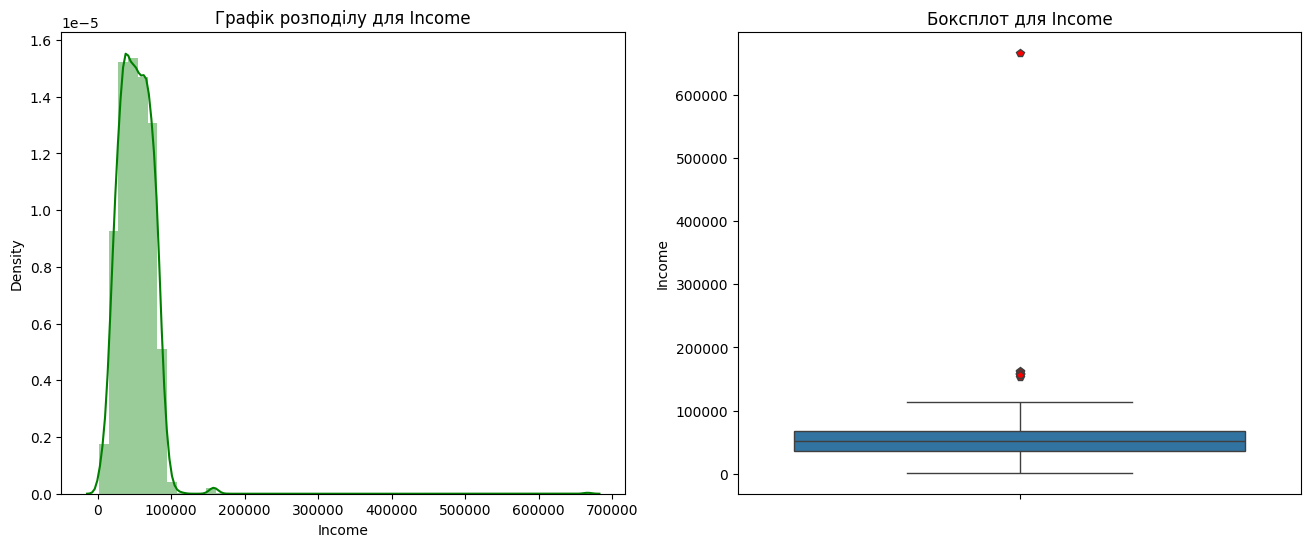

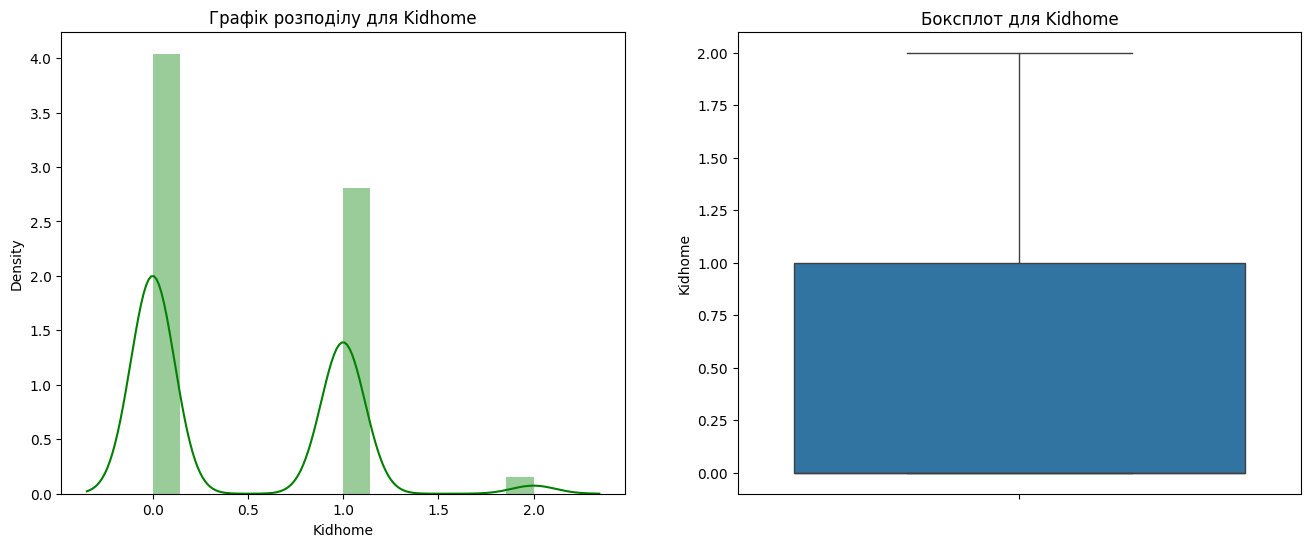

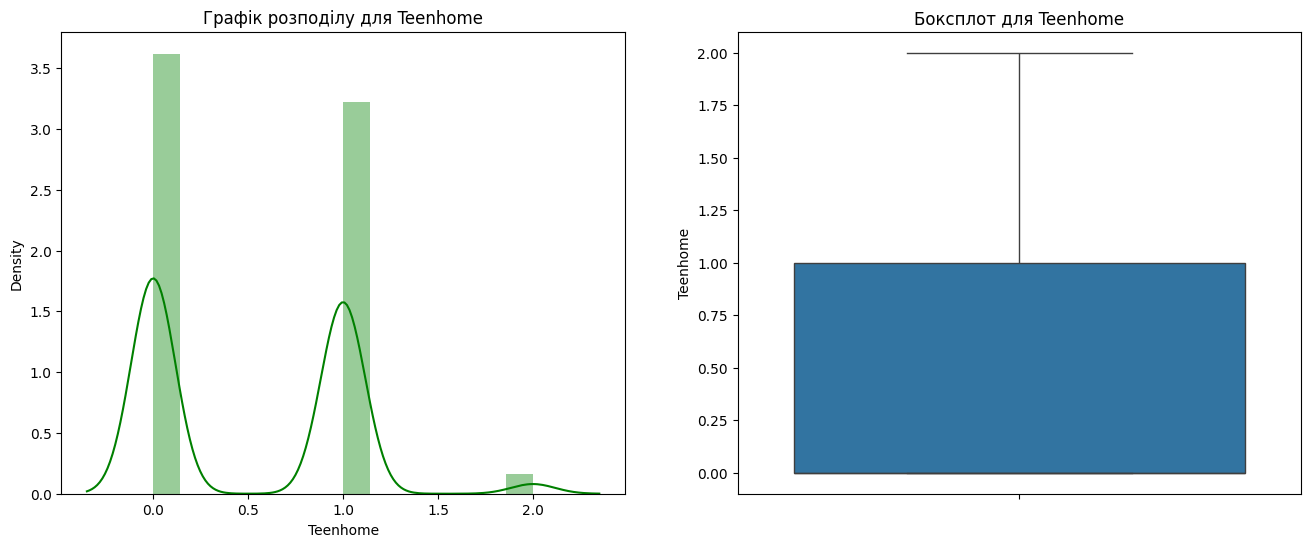

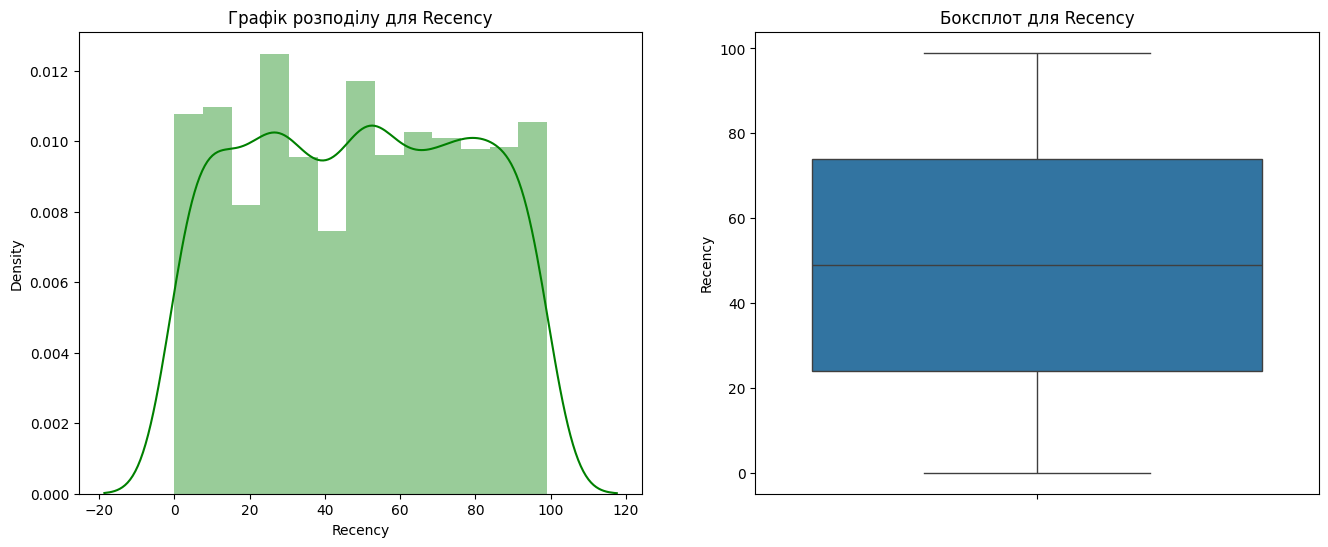

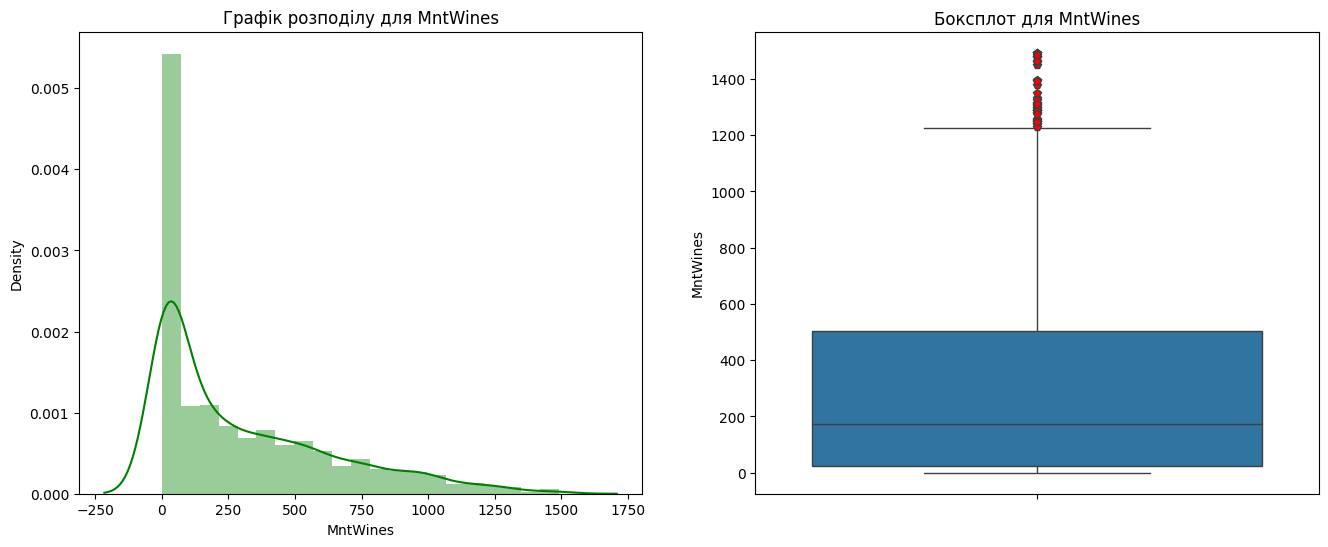

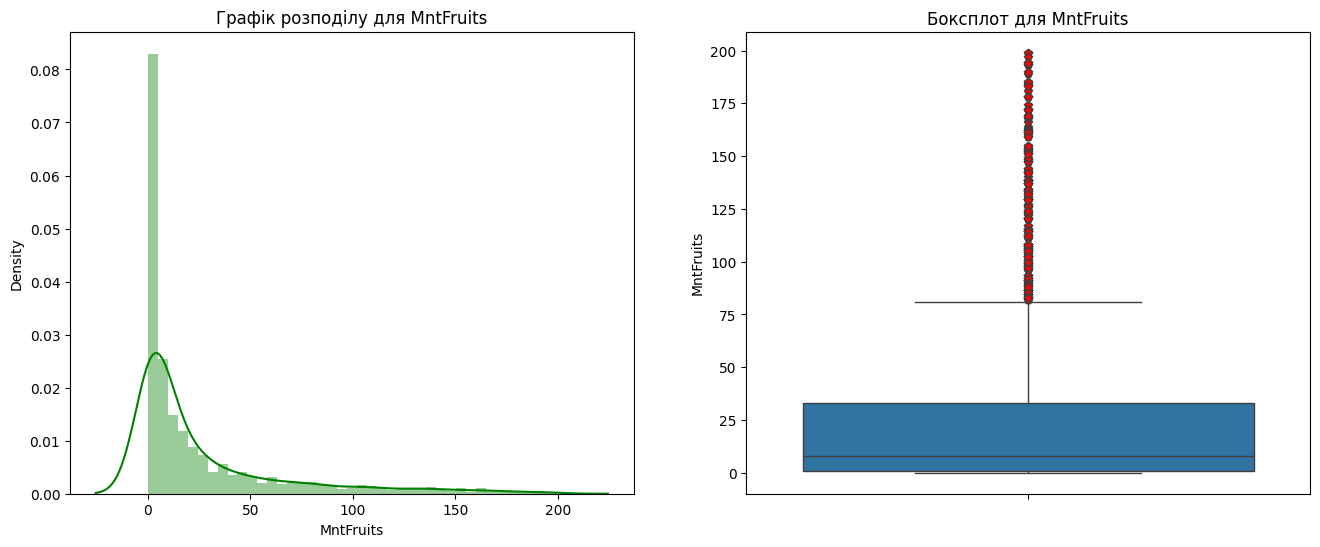

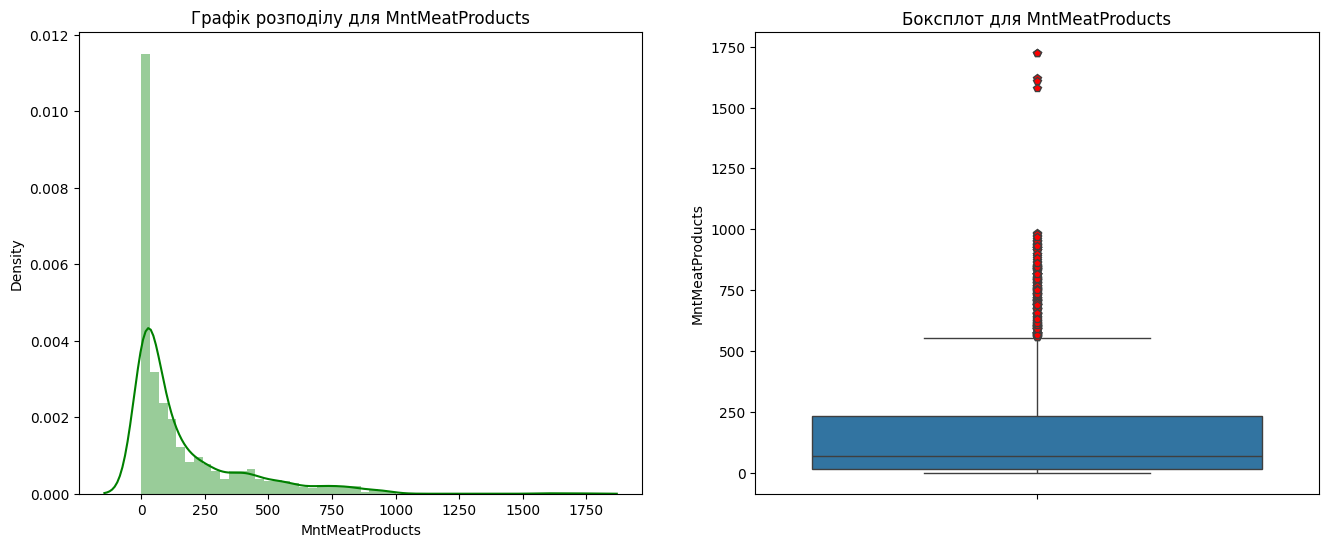

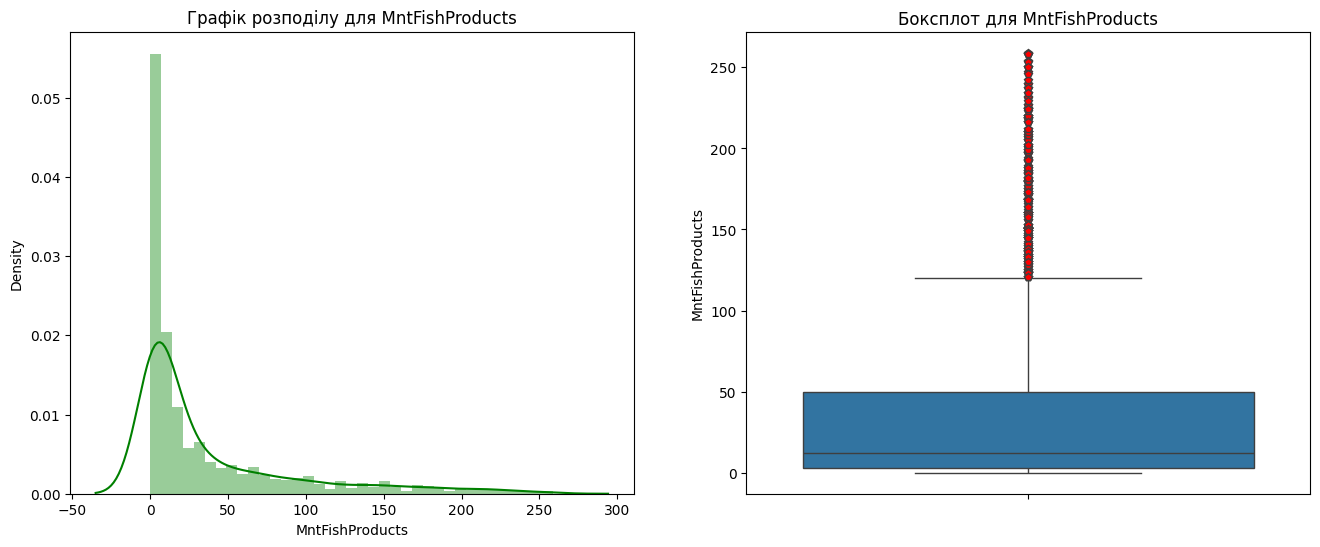

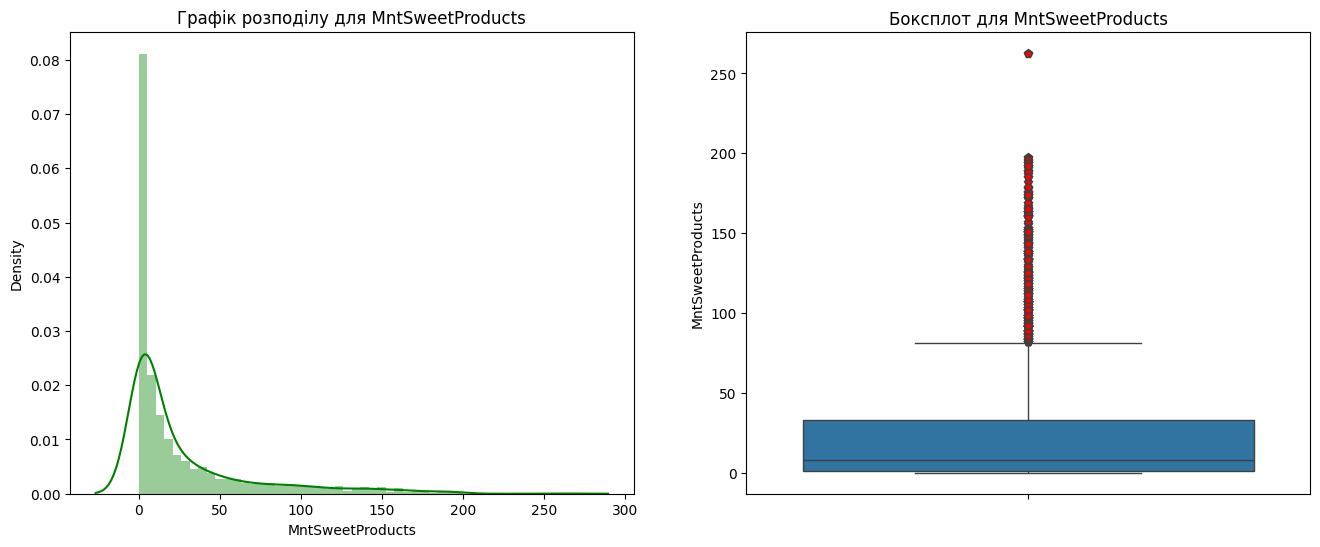

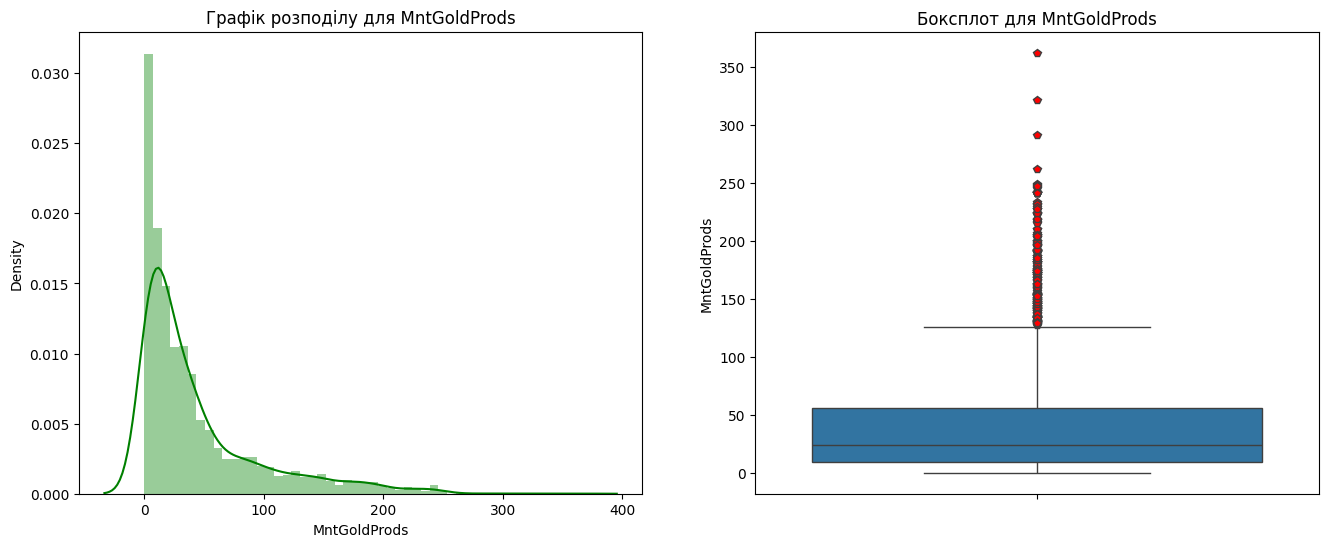

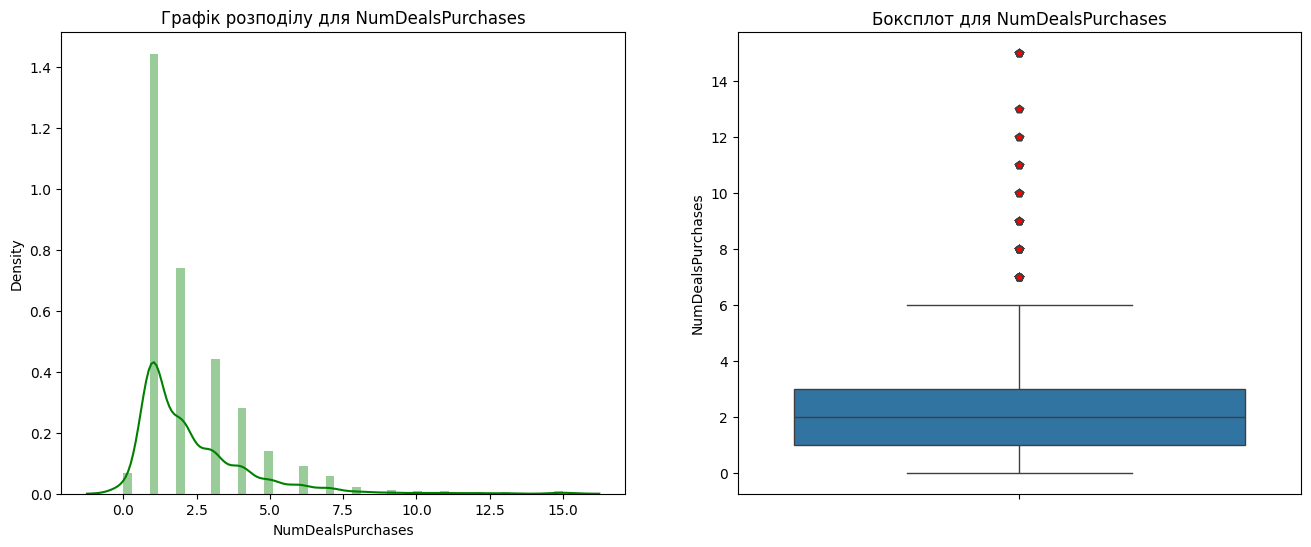

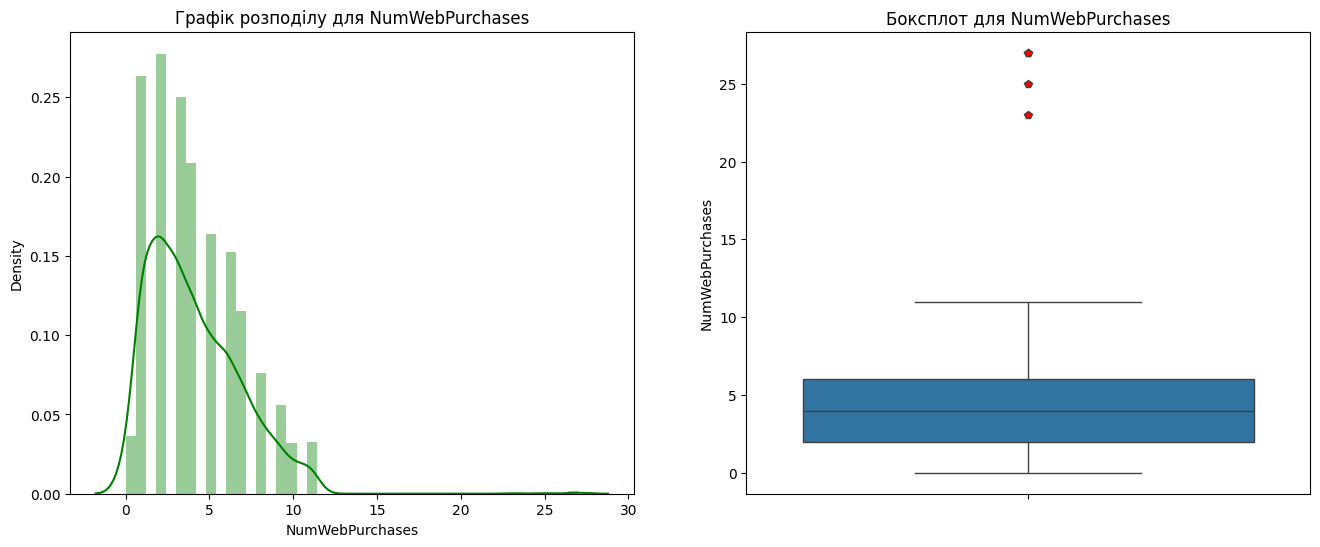

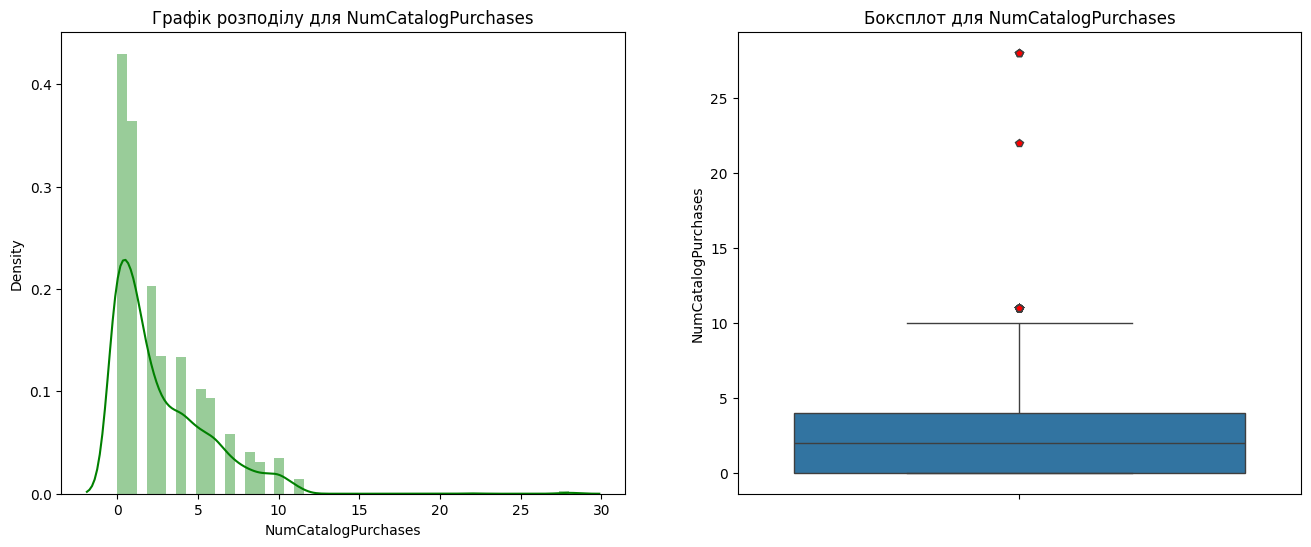

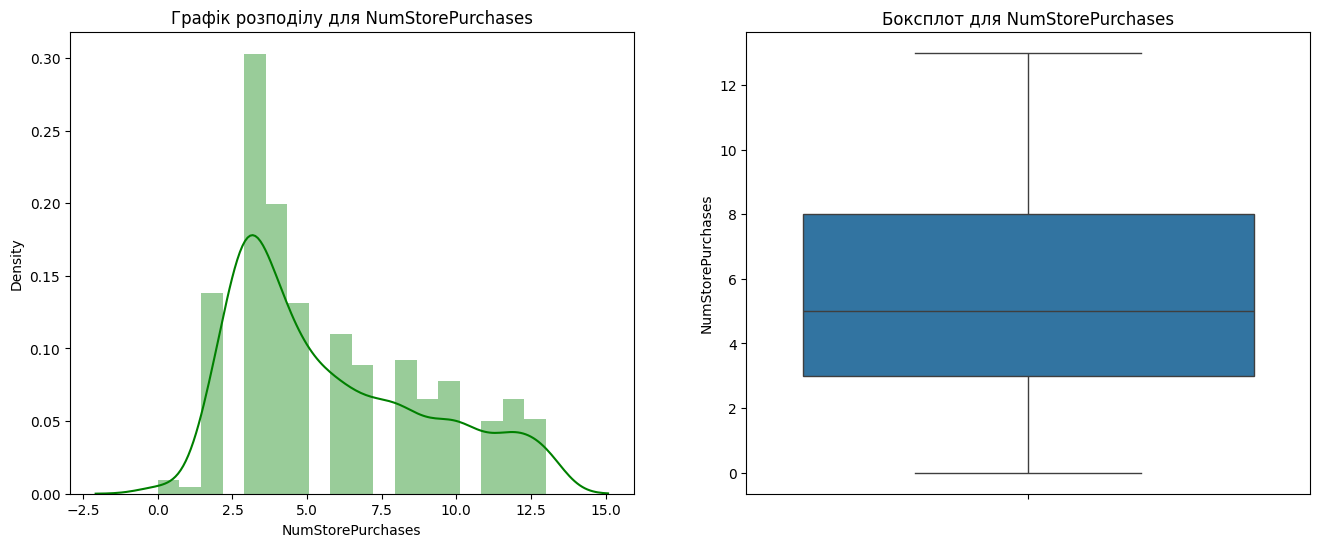

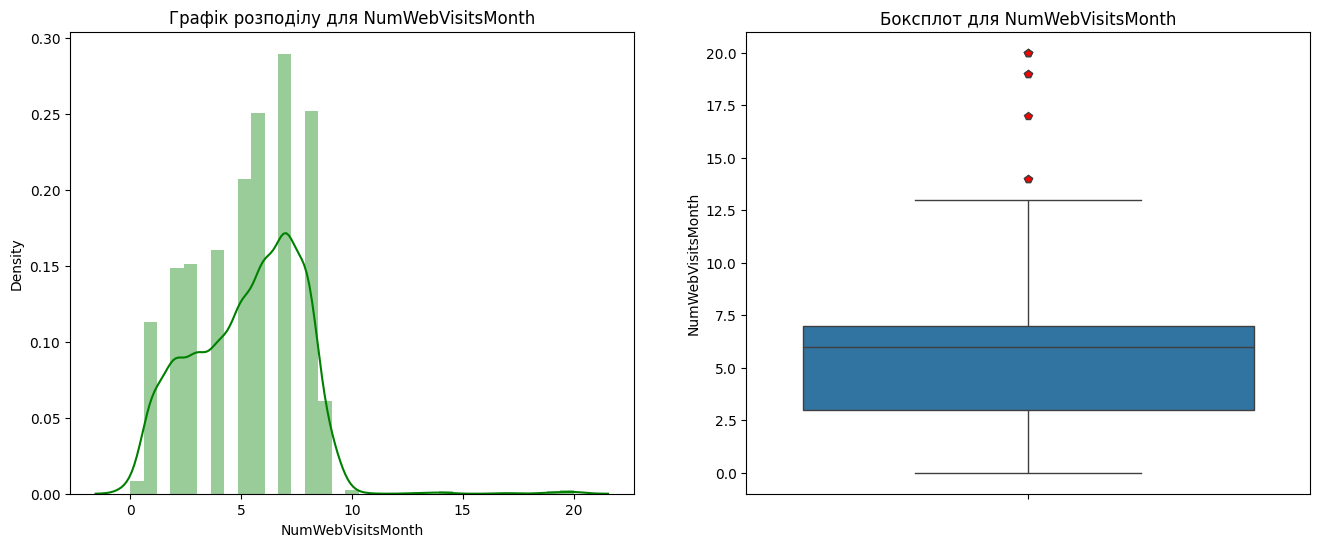

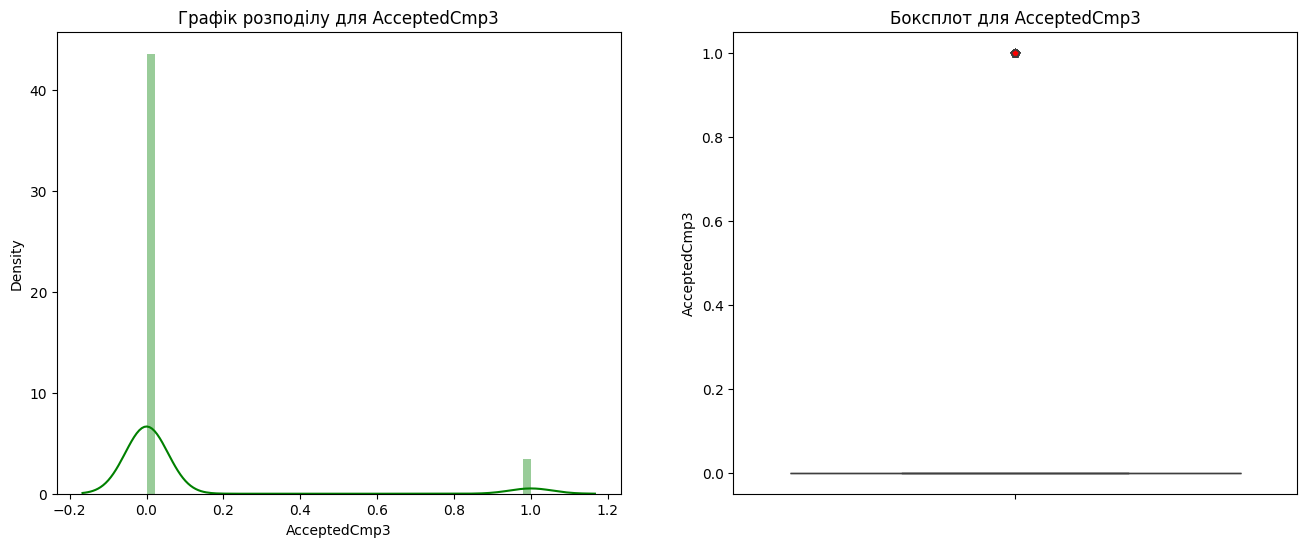

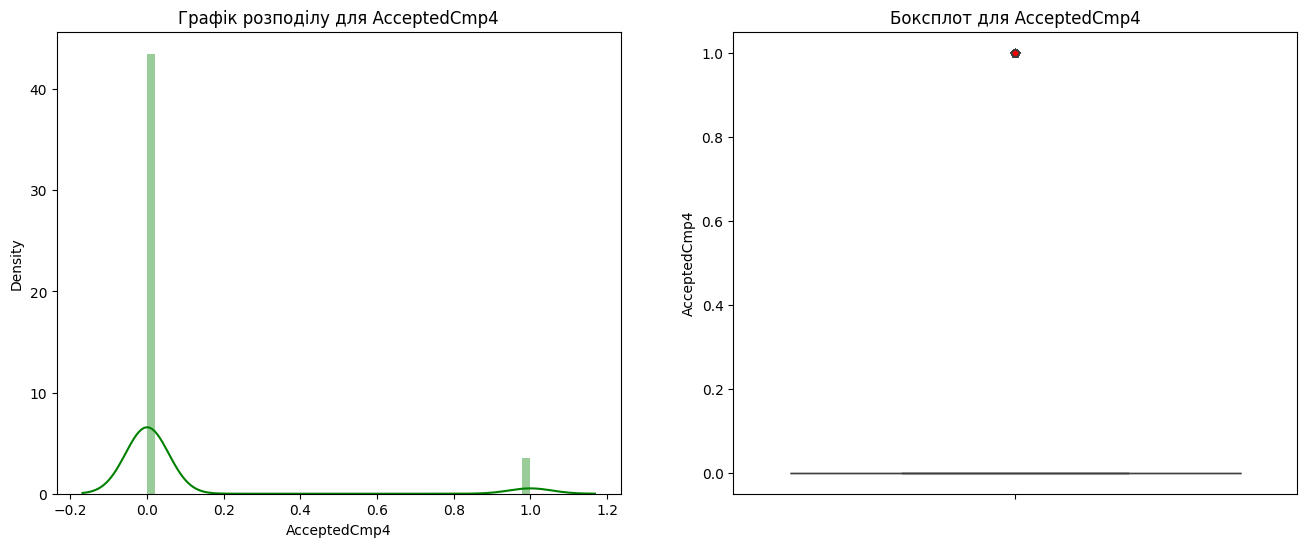

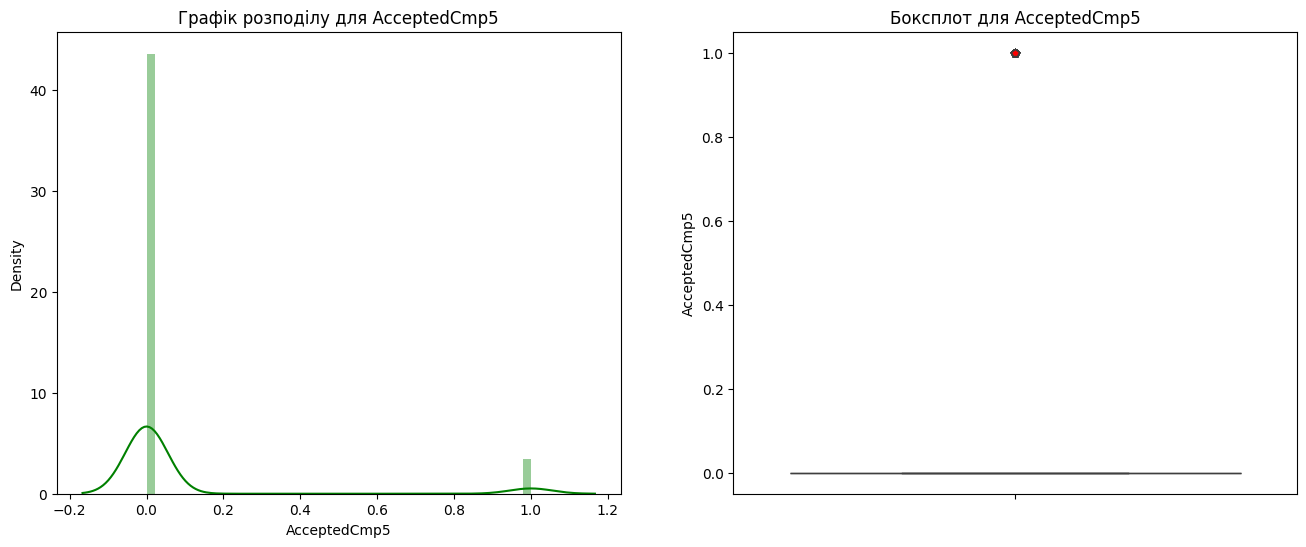

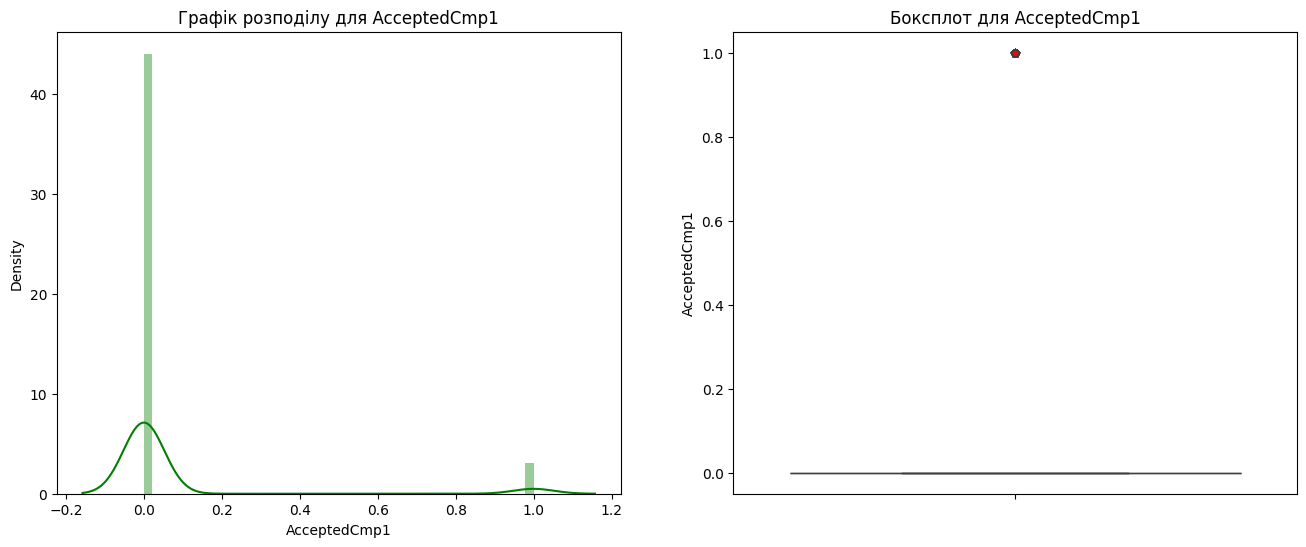

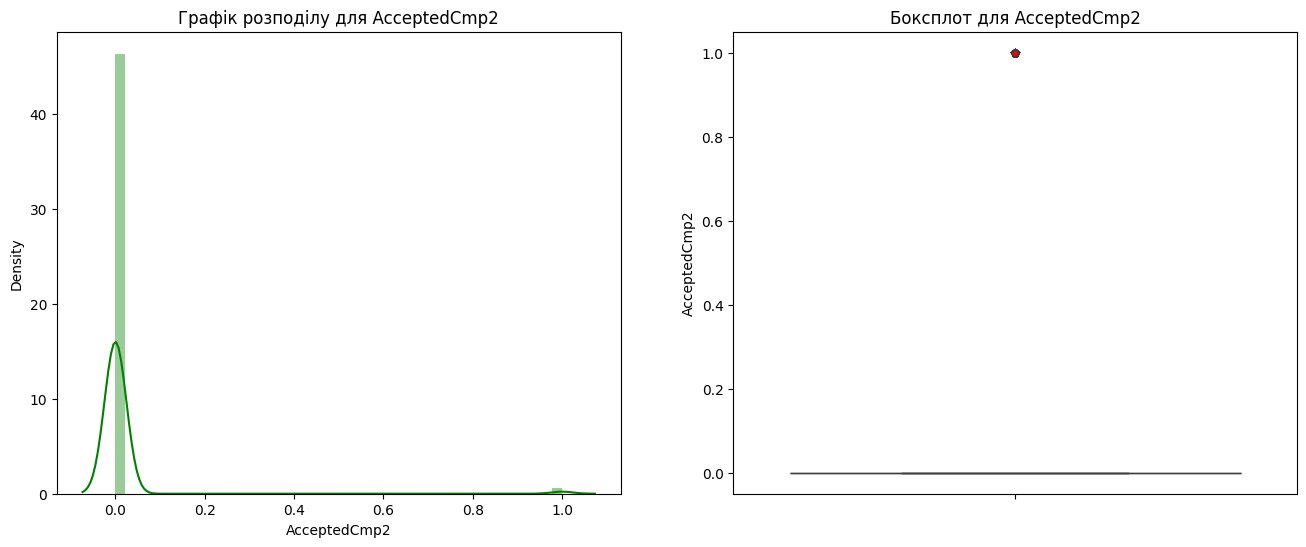

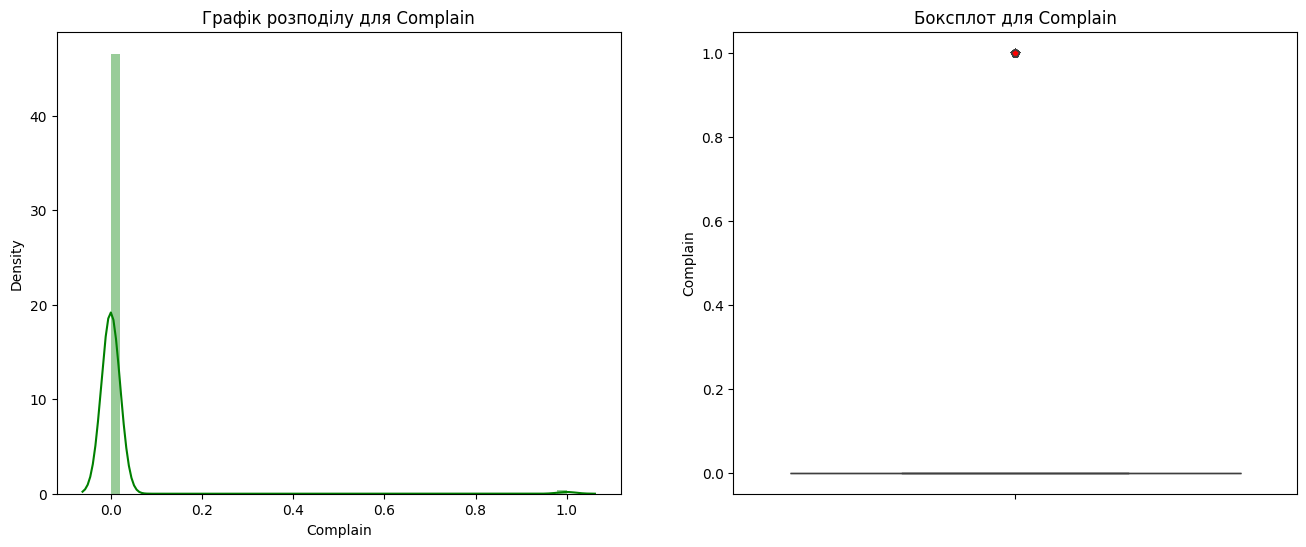

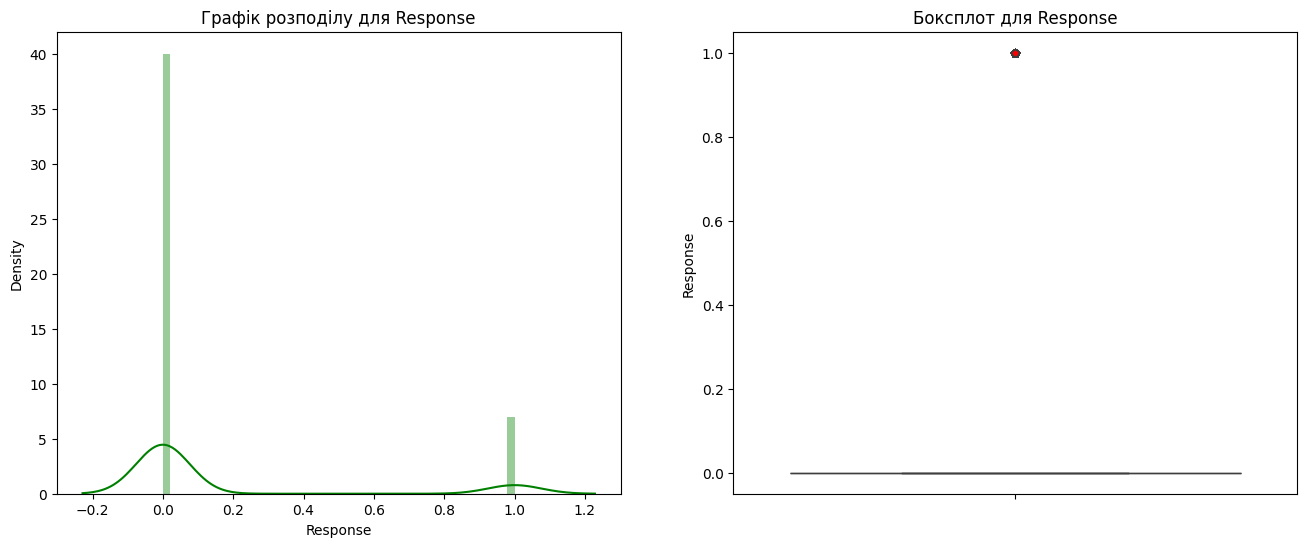

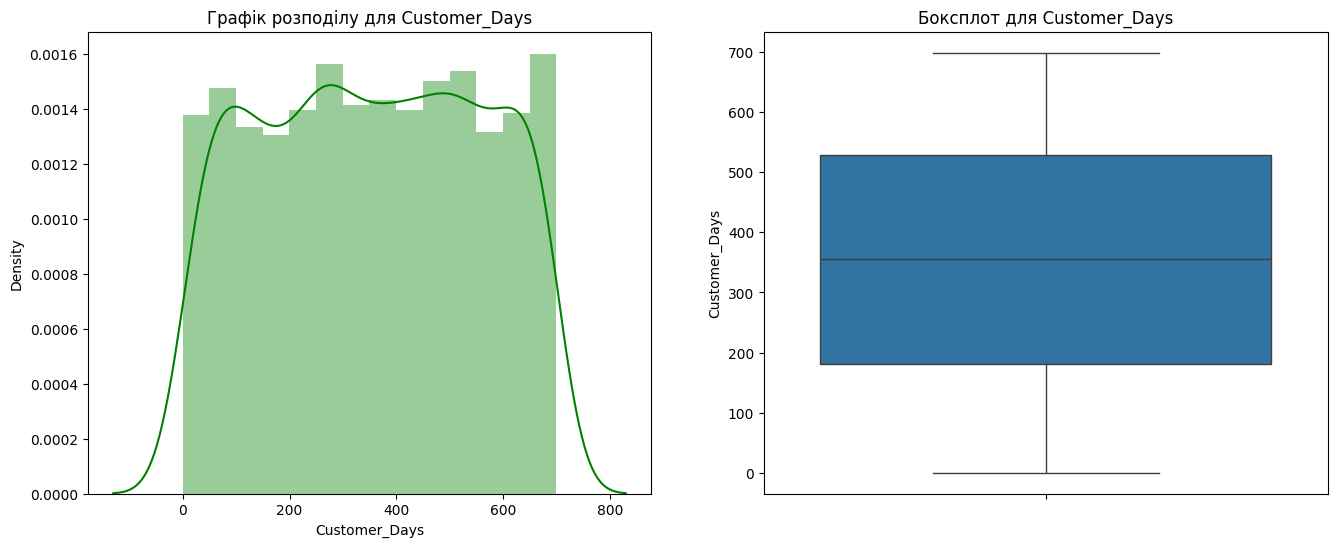

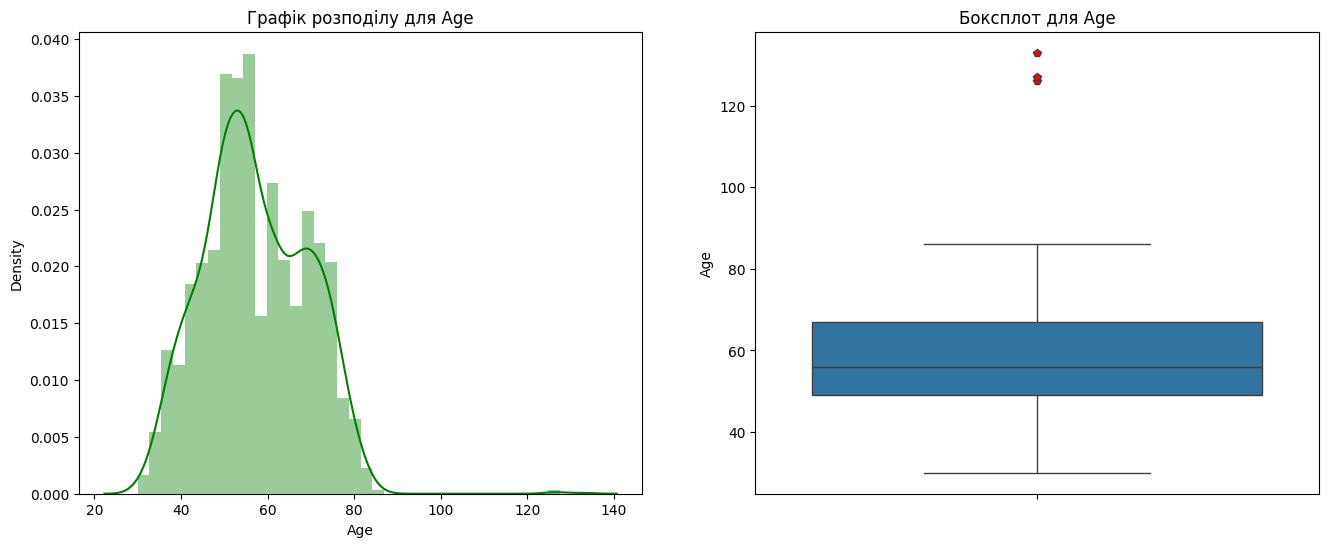

In [47]:
numeric_cols = X.select_dtypes(include='number').columns

for col in numeric_cols:
    dist_box(X, col)

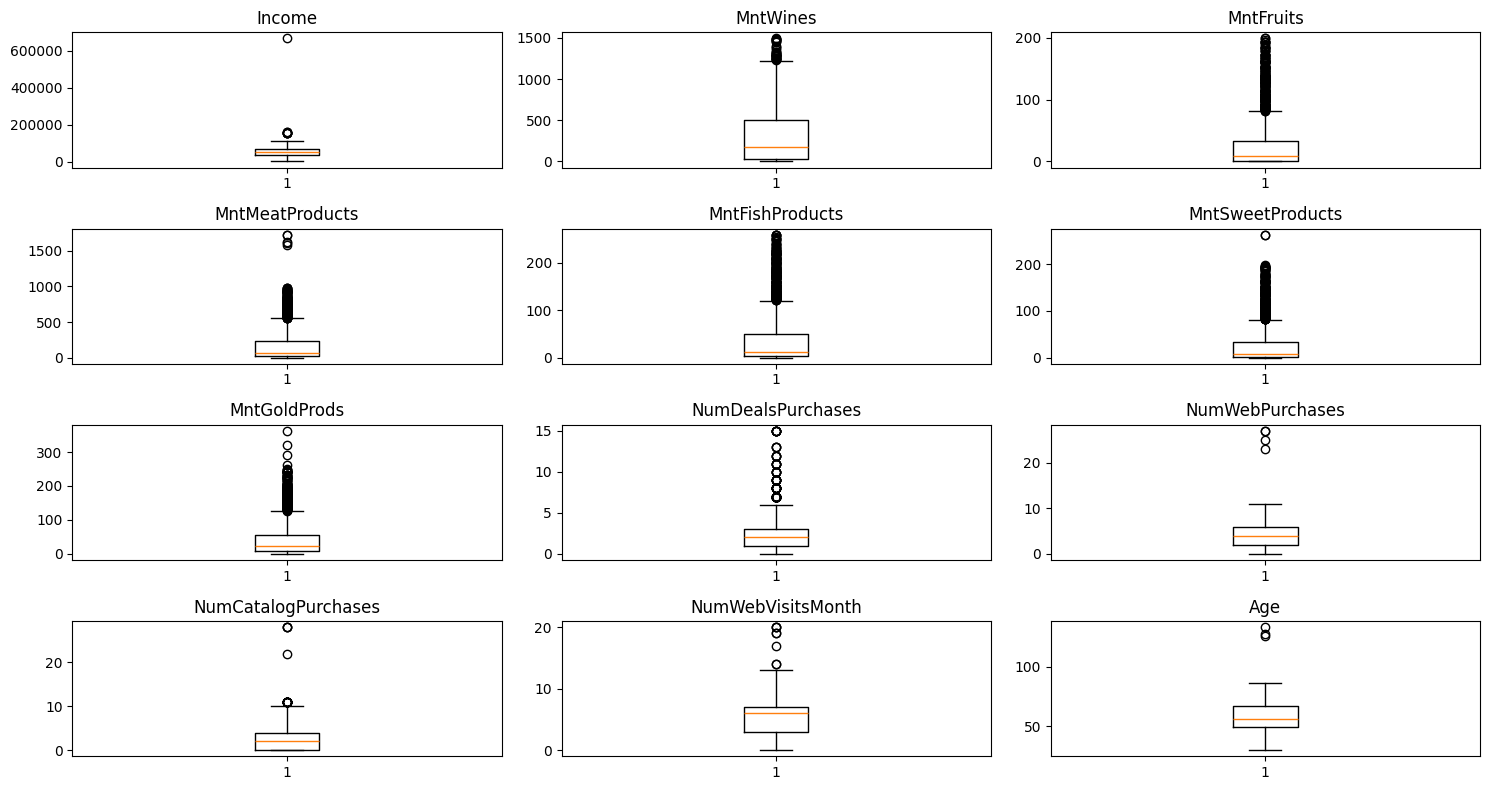

In [48]:
#Ще раз окремо візуалізую колонки з викидами
cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth', 'Age']

fig, axes = plt.subplots(4, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(X[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

Викиди присутні майже в усіх досліджуваних колонках.

In [34]:
# Перевіряємо аномальний дохід
print(X[X['Income'] > 200000][['Income', 'Age']])

# Перевіряємо аномальний вік
print(X[X['Age'] > 100][['Income', 'Age']])

        Income  Age
2233  666666.0   49
      Income  Age
192  36640.0  126
239  60182.0  133
339  83532.0  127


In [52]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Видаляємо аномалії
X = remove_outliers_iqr(X, 'Income')
X = remove_outliers_iqr(X, 'Age')

# Clip для витрат (замінюємо на граничні значення)
cols_to_clip = ['MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth']

for col in cols_to_clip:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    X[col] = X[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print(f'Розмір після видалення: {X.shape}')

Розмір після видалення: (2229, 34)


Аномалії з Income, Age видалила. Викиди з 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth' замінила на граничні значення

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

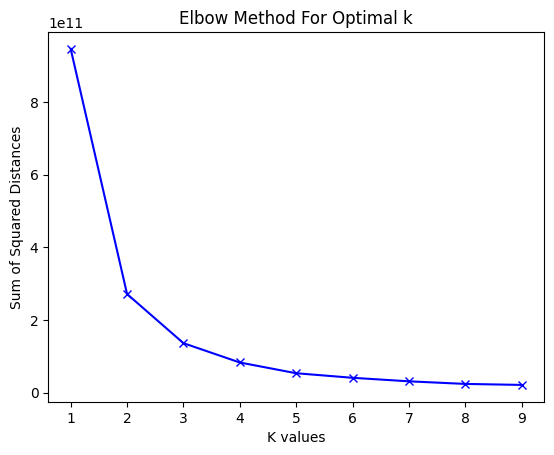

In [54]:
K = range(1, 10)
sum_of_squared_distances = []

for k in K:
  model = KMeans(n_clusters=k, n_init='auto').fit(X)
  sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [55]:
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'k={k}: Silhouette={score:.3f}')

k=3: Silhouette=0.552
k=4: Silhouette=0.533


In [56]:
kmeans_final = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_final = kmeans_final.fit_predict(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df['Cluster'] = labels_final.astype(str)
pca_df['Income'] = X['Income'].values
pca_df['Recency'] = X['Recency'].values
pca_df['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                        X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds']).values
pca_df['TotalPurchases'] = (X['NumDealsPurchases'] + X['NumWebPurchases'] +
                            X['NumCatalogPurchases'] + X['NumStorePurchases']).values

print(pca_df.groupby('Cluster')[['Income', 'Recency', 'TotalSpent', 'TotalPurchases']].mean().round(2))

           Income  Recency  TotalSpent  TotalPurchases
Cluster                                               
0        28174.99    48.29       90.57            7.77
1        75532.96    49.08     1180.98           20.91
2        51670.83    49.90      457.98           15.57


In [57]:
cluster_names = {
    '0': 'Економні',
    '1': 'VIP клієнти',
    '2': 'Середній сегмент'
}
pca_df['Cluster_Name'] = pca_df['Cluster'].map(cluster_names)

fig = px.scatter_3d(
    pca_df,
    x='Income',
    y='TotalPurchases',
    z='TotalSpent',
    color='Cluster_Name',
    title=f'KMeans Clusters (без масштабування) | Silhouette: 0.552'
)
fig.show()

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
score_scaled = silhouette_score(X_scaled, labels_scaled)
print(f'Silhouette (scaled): {score_scaled:.3f}')

# Середні значення по кластерах
pca_df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
pca_df_scaled['Cluster'] = labels_scaled.astype(str)
print(pca_df_scaled.groupby('Cluster')[['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth']].mean().round(2))

Silhouette (scaled): 0.186
         Income  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                                  
0         -0.59     -0.58      -0.58            -0.63            -0.57   
1          0.95      0.89       0.87             0.96             0.86   
2         -1.52     -0.89      -0.42            -0.78            -0.42   

         MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                       
0                   -0.57         -0.44               0.16            -0.39   
1                    0.86          0.66              -0.22             0.62   
2                   -0.39         -0.43              -0.28            -0.83   

         NumCatalogPurchases  NumWebVisitsMonth  
Cluster                                          
0                      -0.62               0.45  
1                       0.95              -0.69  
2     

Для нашого датасету масштабування погіршує результат, тому що Income природно домінує і добре розділяє кластери.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

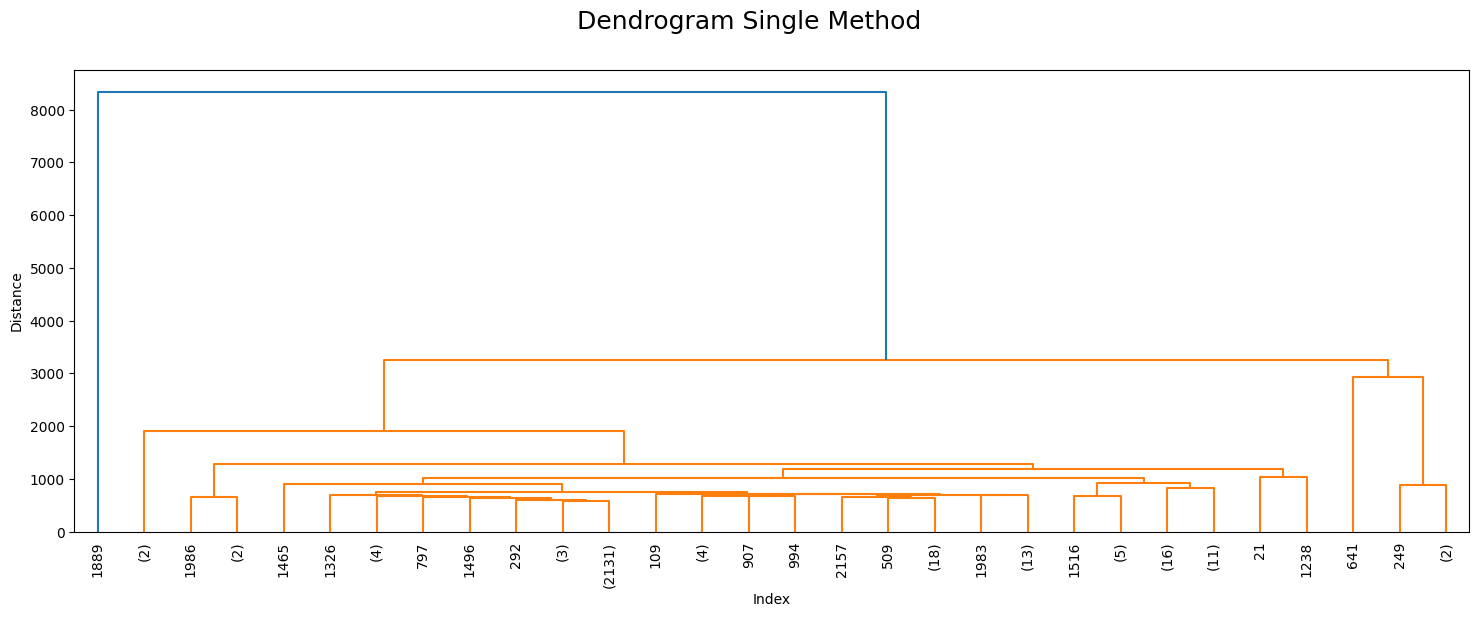

In [63]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

dist_sin = linkage(X, method="single")

plt.figure(figsize=(18, 6))
dendrogram(
    dist_sin,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90
)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('Dendrogram Single Method', fontsize=18)
plt.show()

Розподіл по кластерах (2): {1: 2228, 2: 1}
Розподіл по кластерах (3): {1: 2224, 2: 4, 3: 1}
Silhouette (2 кластери): 0.558
Silhouette (3 кластери): 0.451


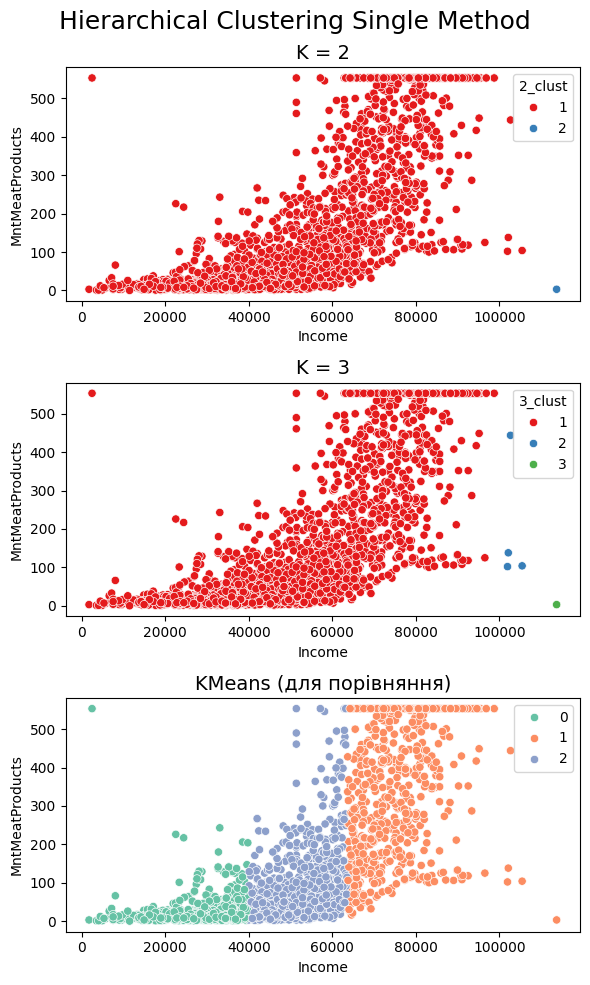

In [66]:
# 1. Плоскі кластеризації
labels_2 = fcluster(dist_sin, 2, criterion='maxclust')
labels_3 = fcluster(dist_sin, 3, criterion='maxclust')

print("Розподіл по кластерах (2):", pd.Series(labels_2).value_counts().to_dict())
print("Розподіл по кластерах (3):", pd.Series(labels_3).value_counts().to_dict())

# 2. Силует
score_2 = silhouette_score(X, labels_2)
score_3 = silhouette_score(X, labels_3)
print(f'Silhouette (2 кластери): {score_2:.3f}')
print(f'Silhouette (3 кластери): {score_3:.3f}')

# 3. Візуалізація
# Додаємо мітки кластерів до датафрейму
df_plot = X.copy()
df_plot['2_clust'] = labels_2
df_plot['3_clust'] = labels_3

plt.figure(figsize=(6, 10))
plt.suptitle("Hierarchical Clustering Single Method", fontsize=18)

plt.subplot(3, 1, 1)
plt.title("K = 2", fontsize=14)
sns.scatterplot(x="Income", y="MntMeatProducts", data=df_plot, hue="2_clust", palette="Set1")

plt.subplot(3, 1, 2)
plt.title("K = 3", fontsize=14)
sns.scatterplot(x="Income", y="MntMeatProducts", data=df_plot, hue="3_clust", palette="Set1")

plt.subplot(3, 1, 3)
plt.title("KMeans (для порівняння)", fontsize=14)
sns.scatterplot(x="Income", y="MntMeatProducts", data=df_plot, hue=labels_final, palette="Set2")

plt.tight_layout()
plt.show()

Ієрархічна агломеративна кластеризація не є вдалим методом кластерного аналізу нашого набору даних. На дендрограмі чітко видно як один клас величезний поглинає інший один лише чітко виражений клас. Single linkage не підходить.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [67]:
from sklearn.cluster import DBSCAN

In [68]:
# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)

# Розподіл (-1 це шум)
print("Розподіл:", pd.Series(labels_db).value_counts().to_dict())
print(f"Шум (викиди): {(labels_db == -1).sum()} точок")

# Силует рахується тільки для точок без шуму
mask = labels_db != -1
if len(set(labels_db[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels_db[mask])
    print(f"Silhouette Score: {score:.3f}")
else:
    print("Недостатньо кластерів для силуету")

Розподіл: {-1: 2229}
Шум (викиди): 2229 точок
Недостатньо кластерів для силуету


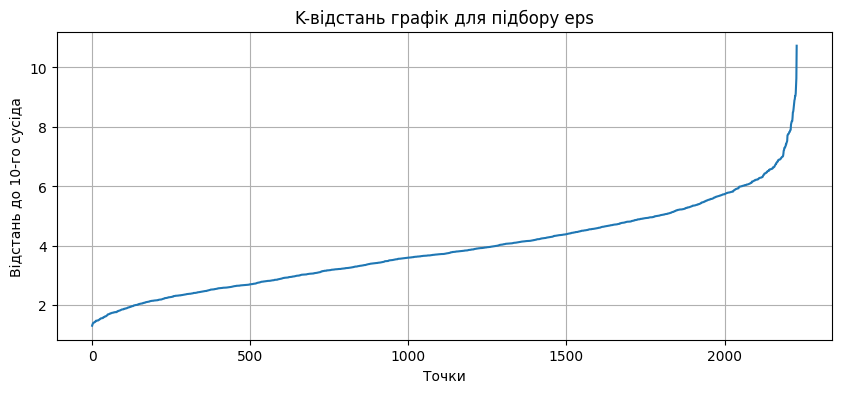

In [69]:
from sklearn.neighbors import NearestNeighbors

# Знаходимо оптимальний eps через k-відстань
neighbors = NearestNeighbors(n_neighbors=10)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# Сортуємо відстані до 10-го сусіда
distances = np.sort(distances[:, 9])

plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.xlabel('Точки')
plt.ylabel('Відстань до 10-го сусіда')
plt.title('K-відстань графік для підбору eps')
plt.grid(True)
plt.show()

In [70]:
for eps in [3, 4, 5, 6]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels_db = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = (labels_db == -1).sum()

    mask = labels_db != -1
    if n_clusters > 1:
        score = silhouette_score(X_scaled[mask], labels_db[mask])
        print(f"eps={eps}: кластерів={n_clusters}, шум={n_noise}, Silhouette={score:.3f}")
    else:
        print(f"eps={eps}: кластерів={n_clusters}, шум={n_noise}, — силует не рахується")

eps=3: кластерів=15, шум=1328, Silhouette=0.231
eps=4: кластерів=6, шум=666, Silhouette=0.042
eps=5: кластерів=3, шум=252, Silhouette=0.195
eps=6: кластерів=3, шум=60, Silhouette=0.224


In [71]:
dbscan = DBSCAN(eps=6, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)

# Додаємо до датафрейму для візуалізації
pca = PCA(n_components=3)
X_pca_db = pca.fit_transform(X_scaled)

pca_df_db = pd.DataFrame(X_pca_db, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df_db['Cluster'] = labels_db.astype(str)  # -1 це шум
pca_df_db['Income'] = X['Income'].values
pca_df_db['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                            X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds']).values
pca_df_db['TotalPurchases'] = (X['NumDealsPurchases'] + X['NumWebPurchases'] +
                                X['NumCatalogPurchases'] + X['NumStorePurchases']).values

fig = px.scatter_3d(
    pca_df_db,
    x='Income',
    y='TotalPurchases',
    z='TotalSpent',
    color='Cluster',
    title=f'DBSCAN eps=6 | Silhouette: 0.224',
    color_discrete_map={'-1': 'grey'}  # шум сірим
)
fig.show()

DBSCAN корисний тут тим що виявляє шум (eps=6: кластерів=3, шум=60, Silhouette=0.224) — 60 аномальних клієнтів які не вписуються в жоден кластер. Але для сегментації KMeans все одно кращий.

In [73]:
#Спробуємо ще метод Complete linkage
dist_complete = linkage(X, method='complete')

lab_2 = fcluster(dist_complete, t=2, criterion='maxclust')
lab_3 = fcluster(dist_complete, t=3, criterion='maxclust')

s2 = silhouette_score(X, lab_2)
s3 = silhouette_score(X, lab_3)

print("Complete linkage:")
print(f"2 кластери: {pd.Series(lab_2).value_counts().to_dict()}, Silhouette={s2:.3f}")
print(f"3 кластери: {pd.Series(lab_3).value_counts().to_dict()}, Silhouette={s3:.3f}")

Complete linkage:
2 кластери: {2: 1219, 1: 1010}, Silhouette=0.597
3 кластери: {1: 1010, 2: 913, 3: 306}, Silhouette=0.525


Complete linkage з 2 кластерами показав найкращий силует 0.597.

In [76]:
# 2 кластери - найкращий силует
pca_df_complete['Cluster_2'] = lab_2.astype(str)
pca_df_complete['Cluster_3'] = lab_3.astype(str)

fig1 = px.scatter_3d(
    pca_df_complete,
    x='Income', y='TotalPurchases', z='TotalSpent',
    color='Cluster_2',
    title='Complete Linkage — 2 кластери | Silhouette: 0.597'
)
fig1.show()

fig2 = px.scatter_3d(
    pca_df_complete,
    x='Income', y='TotalPurchases', z='TotalSpent',
    color='Cluster_3',
    title='Complete Linkage — 3 кластери | Silhouette: 0.525'
)
fig2.show()

Метод Complete linkage
2 кластери (0.597) — математично найкращий, але для маркетингу ділення лише на 2 групи можливо менш корисне чи не раціональне.
3 кластери (0.525) — трохи гірший силует, але дає більш детальну сегментацію як у KMeans.

Тому загальне спостереження: не всі дані потрібно масштабувати для отримання правдивого аналізу при кластеризації. І перший метод в нашому випадку KMeans з трьома кластерами дав найкращий результат. Тому що нам далі як компанії потрібно працювати з конкретним сегментом клієнтів для просування своїх товарів. А, правильніший розподіл клієнтів - і була метою дослідження.